In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

## Exploratory Data Analysis (EDA)

**Objective**
The goal of this EDA is to understand the statistical and temporal properties of retail demand data
in order to make informed decisions about:
- data cleaning
- feature engineering
- modeling strategy
- evaluation metrics

This analysis is performed on a sampled subset of the M5 dataset
(1 store × 200 items) to enable reproducibility in constrained environments.


## Setup

In [15]:
def find_repo_root(
    marker_files=("README.md", "pyproject.toml", "requirements.txt")
) -> Path:
    """
    Walk up from the current directory until we find a repo root marker.
    """
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if any((parent / m).exists() for m in marker_files):
            return parent
    raise FileNotFoundError(
        "Could not find repo root. Run this notebook inside the project folder "
        "or ensure README.md/requirements.txt exists at repo root."
    )


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data" / "processed" / "m5_daily_sample.parquet"
DATA_PATH

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPO_ROOT

WindowsPath('C:/Users/imanb/retail_demand/retail-demand-forecasting-delayed-labels')

## Data loading

In [16]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing file: {DATA_PATH}\n\n"
        "Run preprocessing first:\n"
        "python src/data/preprocess.py "
        "--sample_stores 1 --sample_items 200 "
        "--out_path data/processed/m5_daily_sample.parquet"
    )

print("Repo root:", REPO_ROOT)
print("Data path:", DATA_PATH)

df = pd.read_parquet(DATA_PATH)
df.info()
df.head()

Repo root: C:\Users\imanb\retail_demand\retail-demand-forecasting-delayed-labels
Data path: C:\Users\imanb\retail_demand\retail-demand-forecasting-delayed-labels\data\processed\m5_daily_sample.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382600 entries, 0 to 382599
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          382600 non-null  datetime64[ns]
 1   d             382600 non-null  object        
 2   wm_yr_wk      382600 non-null  int64         
 3   item_id       382600 non-null  object        
 4   dept_id       382600 non-null  object        
 5   cat_id        382600 non-null  object        
 6   store_id      382600 non-null  object        
 7   state_id      382600 non-null  object        
 8   sales         382600 non-null  int64         
 9   sell_price    324024 non-null  float64       
 10  event_name_1  30800 non-null   object        
 11  event_type_1  30800 

,date,d,wm_yr_wk,item_id,dept_id,cat_id,store_id,state_id,sales,sell_price,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,d_1,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,3,2.0,None,None,None,None,0,0,0
1,2011-01-30,d_2,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2.0,None,None,None,None,0,0,0
2,2011-01-31,d_3,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2.0,None,None,None,None,0,0,0
3,2011-02-01,d_4,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,1,2.0,None,None,None,None,1,1,0
4,2011-02-02,d_5,11101,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,4,2.0,None,None,None,None,1,0,1


### Data overview

The dataset represents daily item-level sales with calendar and pricing context.
Each row corresponds to a `(store_id, item_id, date)` combination.

### Row definition
Each row represents a single daily observation for a specific `(store_id, item_id, date)` with sales (target) and joined context from:
- calendar features (events, SNAP flags)
- weekly sell price (when available)


## ## Data integrity checks
Quick sanity checks to validate assumptions before deeper EDA.

In [17]:
# 1) Key uniqueness
key_cols = ["store_id", "item_id", "date"]
dup_rate = df.duplicated(key_cols).mean()
print("Duplicate key rate:", dup_rate)

# 2) Date continuity within a series (spot check)
one_series = (
    df.groupby(["store_id", "item_id"]).size().sort_values(ascending=False).index[0]
)
ts = df[
    (df["store_id"] == one_series[0]) & (df["item_id"] == one_series[1])
].sort_values("date")
missing_days = ts["date"].diff().dt.days.dropna().value_counts().sort_index()
print("Most common day gaps (should be mostly 1):")
print(missing_days.head(10))

# 3) Sales validity
print("Any negative sales?", (df["sales"] < 0).any())
print("Sales dtype:", df["sales"].dtype)

# 4) Basic counts for context
print("Rows:", len(df))
print("Stores:", df["store_id"].nunique(), "| Items:", df["item_id"].nunique())
print("Date range:", df["date"].min(), "->", df["date"].max())

Duplicate key rate: 0.0
Most common day gaps (should be mostly 1):
date
1.0    1912
Name: count, dtype: int64
Any negative sales? False
Sales dtype: int64
Rows: 382600
Stores: 1 | Items: 200
Date range: 2011-01-29 00:00:00 -> 2016-04-24 00:00:00


## Data integrity checks — summary

Key validation results:

- **Uniqueness:**  
  No duplicate records were found for the `(store_id, item_id, date)` key  
  *(duplicate rate = 0.0)*, confirming a one-row-per-day structure per item.

- **Temporal continuity:**  
  The most common gap between consecutive dates is **1 day**, indicating a
  complete and continuous daily time series with no missing dates.

- **Target validity:**  
  - No negative sales values were observed.
  - `sales` is stored as an integer type, consistent with count data.

- **Dataset scope:**  
  - **Rows:** 382,600  
  - **Stores:** 1  
  - **Items:** 200  
  - **Date range:** 2011-01-29 → 2016-04-24  

**Conclusion:**  
The dataset satisfies key integrity assumptions required for time-series
forecasting. There are no structural issues related to duplication, missing
dates, or invalid target values. The data is suitable for downstream modeling
and evaluation without corrective preprocessing at this stage.


## Sales distribution

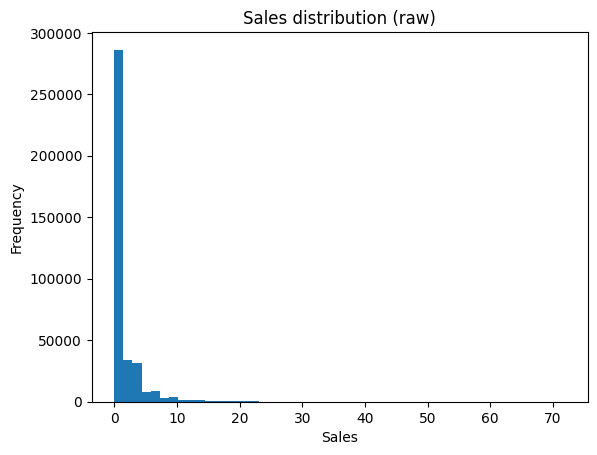

In [18]:
# Sales distribution
df["sales"].plot(kind="hist", bins=50, title="Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales distribution (raw)")
plt.show()

In [19]:
plt.savefig(FIG_DIR / "sales_hist.png", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

In [20]:
df["sales"].describe()

count    382600.000000
mean          1.335868
std           2.936366
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          72.000000
Name: sales, dtype: float64

In [21]:
(df["sales"] == 0).mean()

np.float64(0.5987872451646629)

### sell_price null validation (product introduction hypothesis)

Hypothesis: null `sell_price` occurs because the product was not yet in the catalog at that date. The M5 `sell_prices.csv` has one row per `(store_id, item_id, wm_yr_wk)` only when the product has a price for that week; products introduced later have no price row for early weeks, so the left join yields null.

In [22]:
# Per-product first price date and first sale date
def _first_date(g, condition):
    subset = g.loc[condition]
    return subset["date"].min() if len(subset) > 0 else pd.NaT

intro = (
    df.groupby(["store_id", "item_id"])
    .apply(
        lambda g: pd.Series(
            {
                "first_price_date": _first_date(g, g["sell_price"].notna()),
                "first_sale_date": _first_date(g, g["sales"] > 0),
            }
        )
    )
    .reset_index()
)

# All null-price rows should be strictly before first_price_date for that product
null_rows = df[df["sell_price"].isna()].copy()
merged = null_rows.merge(intro, on=["store_id", "item_id"])
nulls_before_first_price = (merged["date"] < merged["first_price_date"]).sum()
total_nulls = len(null_rows)

print("Hypothesis check: null sell_price occurs only before product introduction")
print(f"  Rows with null sell_price: {total_nulls}")
print(f"  Of those, date < first_price_date: {nulls_before_first_price}")
print(f"  Match (100% expected): {nulls_before_first_price == total_nulls}")

# Overlap: first_price_date vs first_sale_date
intro_valid = intro.dropna(subset=["first_price_date", "first_sale_date"])
same_or_earlier = (intro_valid["first_price_date"] <= intro_valid["first_sale_date"]).sum()
print(f"\nFirst price vs first sale (products with both):")
print(f"  first_price_date <= first_sale_date: {same_or_earlier} / {len(intro_valid)}")

Hypothesis check: null sell_price occurs only before product introduction
  Rows with null sell_price: 58576
  Of those, date < first_price_date: 58576
  Match (100% expected): True

First price vs first sale (products with both):
  first_price_date <= first_sale_date: 200 / 200


C:\Users\imanb\AppData\Local\Temp\ipykernel_35876\731229421.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


### Sales distribution insights

Key observations:
- Approximately 60% of daily observations have zero sales.
- The distribution is highly right-skewed with occasional demand spikes.
- Sales values are discrete and non-negative.

Implications:
- Zero sales are valid observations, not missing values.
- The data exhibits strong zero-inflation.
- Modeling approaches assuming Gaussian noise are likely inappropriate.

**Metric implication**
Given strong zero-inflation and intermittency, metrics like MAE / sMAPE are often more informative than RMSE on raw counts.
Baselines such as seasonal naïve or moving-average should be included for a fair benchmark.


In [11]:
missing_table = pd.DataFrame(
    {"missing_count": df.isna().sum(), "missing_pct": df.isna().mean().mul(100)}
)

missing_table = missing_table.round(2).sort_values("missing_pct", ascending=False)

missing_table[missing_table["missing_pct"] > 0]

,missing_count,missing_pct
event_type_2,381800,99.79
event_name_2,381800,99.79
event_name_1,351800,91.95
event_type_1,351800,91.95
sell_price,58576,15.31


In [12]:
df.groupby(df["sell_price"].isna())["sales"].describe()

,count,mean,std,min,25%,50%,75%,max
sell_price,,,,,,,,
False,324024.0,1.577362,3.1305,0.0,0.0,0.0,2.0,72.0
True,58576.0,0.000000,0.0000,0.0,0.0,0.0,0.0,0.0


<Axes: title={'center': 'Share of missing prices over time'}, xlabel='date'>

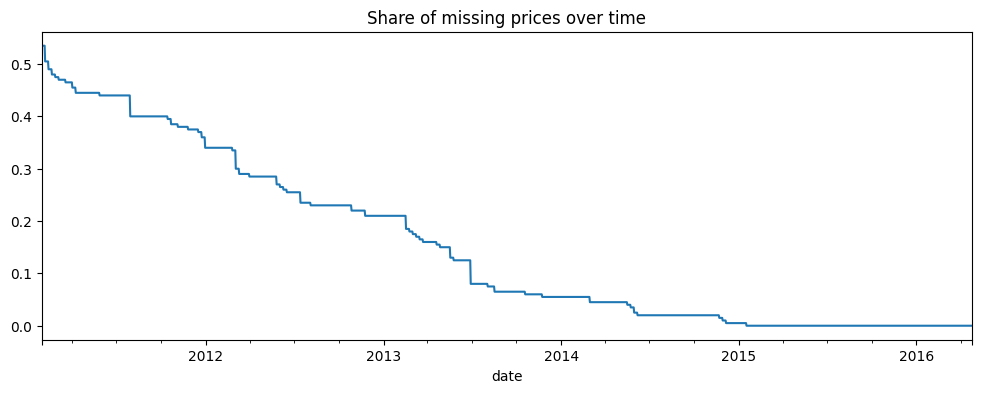

In [13]:
(
    df.assign(price_missing=df["sell_price"].isna())
    .groupby("date")["price_missing"]
    .mean()
    .plot(title="Share of missing prices over time", figsize=(12, 4))
)

In [13]:
plt.savefig(FIG_DIR / "Share of missing prices over time", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

In [14]:
df.assign(price_missing=df["sell_price"].isna()).groupby("price_missing")["sales"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
price_missing,,,
False,324024,1.577362,0.0
True,58576,0.000000,0.0


### Missing data summary

Key observations:
- Event-related features are highly sparse (e.g., `event_type_2` missing ~99.8%), which is expected because most days have no events.
- `sell_price` is missing for a meaningful subset of rows (~15.3%).

Interpretation:
- Event missingness is structural ("no event") rather than data quality failure.
- **Null `sell_price` is structural**: validation above confirms that 100% of null-price rows occur at dates *before* the product's first price date. The M5 `sell_prices.csv` has a row only when a product is actively sold in that week; products introduced later have no price for early weeks, so the left join yields null. Rows with null price have zero sales (product not yet in catalog).

Decision:
- Encode event missingness as an explicit "no event" category (or boolean flags).
- Keep null `sell_price` as "no price" (or let the model treat it as a distinct category via `use_missing`) rather than imputing; filling with 0 or mean would misrepresent "not yet introduced."


## Time-series spot check (single item)

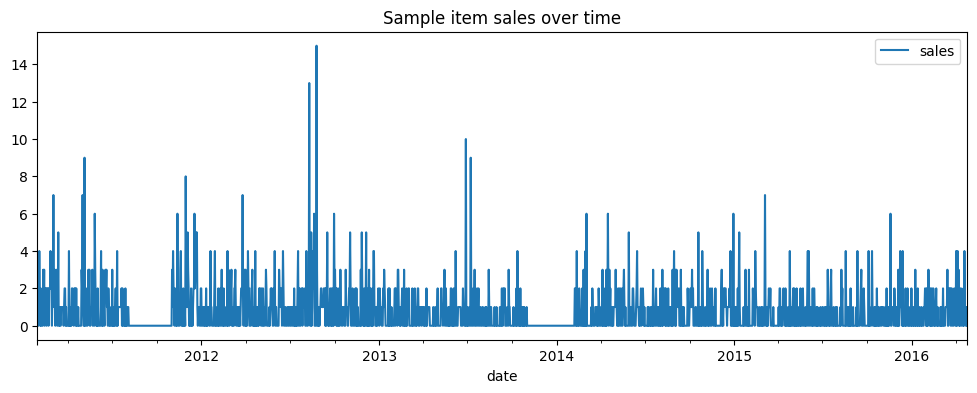

In [15]:
sample_key = df.loc[df["sales"] > 0, ["store_id", "item_id"]].drop_duplicates().iloc[0]

mask = (df["store_id"] == sample_key["store_id"]) & (
    df["item_id"] == sample_key["item_id"]
)

df.loc[mask].plot(x="date", y="sales", figsize=(12, 4))
plt.title("Sample item sales over time")
plt.show()

In [16]:
plt.savefig(FIG_DIR / "Sample item sales over time", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

### Price and demand relationship

This analysis explores whether price variations show a clear
relationship with daily demand.


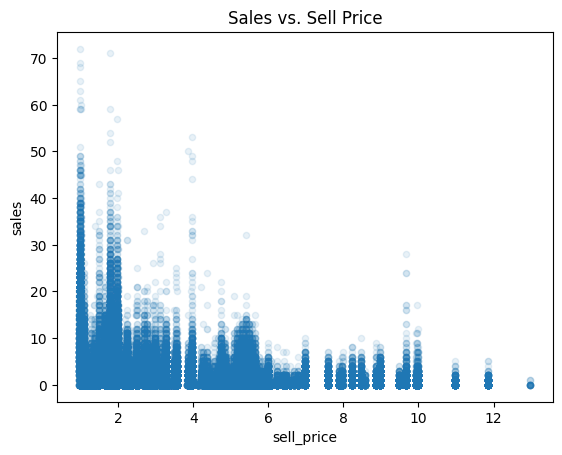

In [17]:
df.plot.scatter(x="sell_price", y="sales", alpha=0.1)
plt.title("Sales vs. Sell Price")
plt.show()

In [18]:
plt.savefig(FIG_DIR / "Sales vs Sell Price", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

**Observation**
- Relationship appears weak at the daily level.
- High variance suggests price elasticity may operate over longer horizons.

**Decision**
- Retain price as a feature.
- Avoid strong assumptions about linear price elasticity.

Note: price-demand relationships are typically clearer at aggregated levels (weekly or category/store) and with controls for seasonality/events; daily scatter may look noisy even when elasticity exists.


## Event impact check

In [19]:
df.groupby("event_name_1")["sales"].mean().sort_values(ascending=False).head(10)

event_name_1
ValentinesDay     1.918333
Easter            1.804000
Chanukah End      1.547000
Eid al-Fitr       1.484000
LaborDay          1.451000
Father's day      1.400000
MemorialDay       1.386000
Ramadan starts    1.372000
OrthodoxEaster    1.362500
Mother's day      1.357000
Name: sales, dtype: float64

## Temporal demand behavior

**Intent:** Inspect individual item time series to understand intermittency, demand bursts, and possible seasonality.  
This helps decide whether we should use lag features, rolling statistics, and which evaluation metrics are appropriate for a zero-inflated series.

Selected series: CA_1 FOODS_1_019 | Non-zero days: 1008
Observations: 1913
Zero-sales rate: 0.473
Mean sales: 4.052 | Std sales: 5.255
Avg gap between non-zero days: 1.8987090367428003


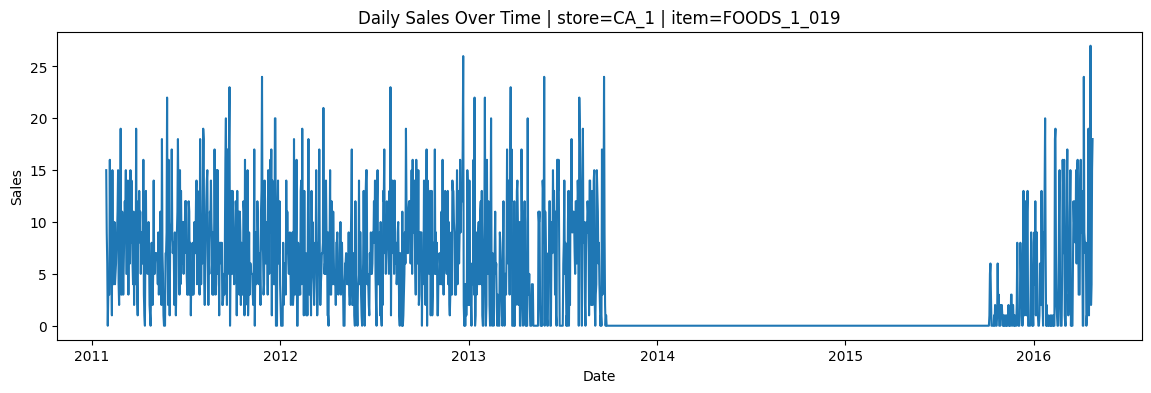

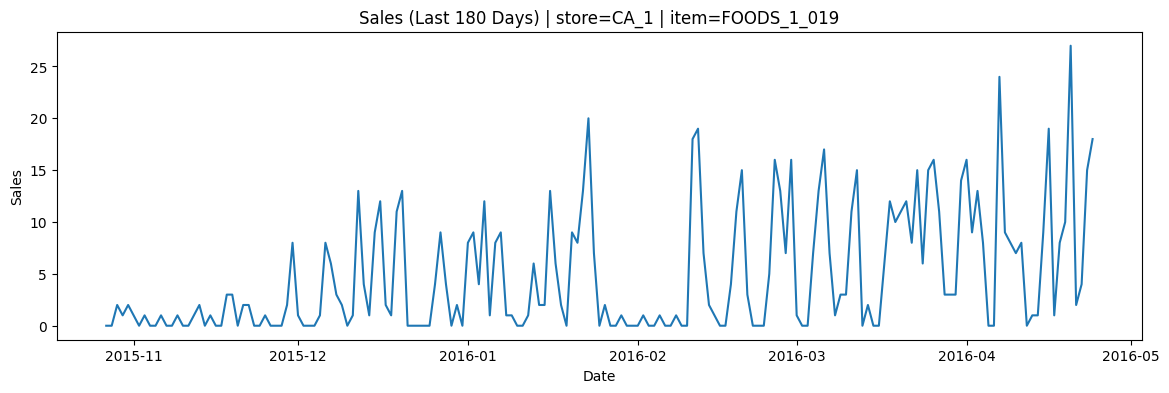

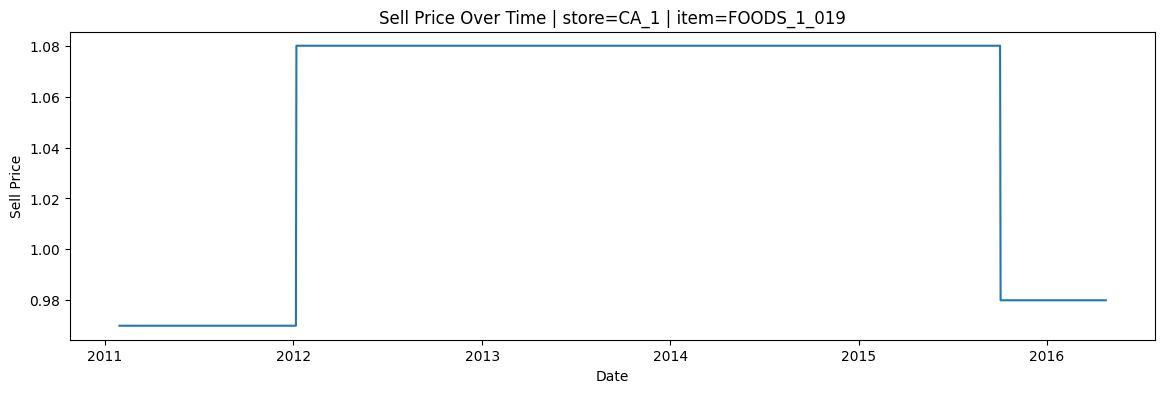

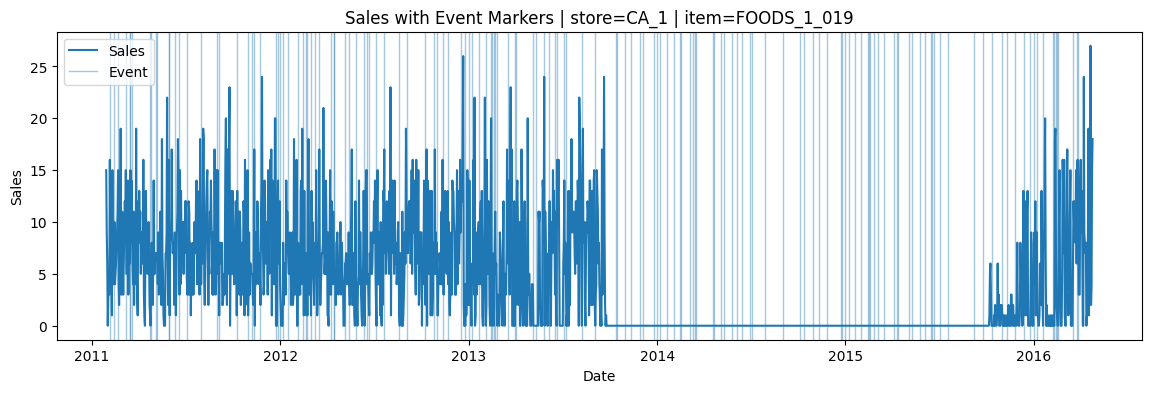

In [20]:
# Basic key sanity checks
required_cols = {"store_id", "item_id", "date", "sales"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Pick a representative series:
# - choose a (store, item) with at least N non-zero days (so it's not all zeros)
min_nonzero_days = 30
seed = 42
rng = np.random.default_rng(seed)

series_stats = (
    df.assign(nonzero=(df["sales"] > 0).astype(int))
    .groupby(["store_id", "item_id"])["nonzero"]
    .sum()
)

eligible = series_stats[series_stats >= min_nonzero_days]
if eligible.empty:
    raise ValueError(
        "No eligible series; reduce min_nonzero_days or increase sample size."
    )

# pick one eligible series at random, but reproducible
idx = rng.integers(0, len(eligible))
store_id, item_id = eligible.index[idx]
print(
    "Selected series:", store_id, item_id, "| Non-zero days:", int(eligible.iloc[idx])
)

ts = (
    df[(df["store_id"] == store_id) & (df["item_id"] == item_id)]
    .sort_values("date")
    .reset_index(drop=True)
)

# --- Quantify intermittency / burstiness ---
n = len(ts)
zero_rate = (ts["sales"] == 0).mean()
mean_sales = ts["sales"].mean()
std_sales = ts["sales"].std()

# Average gap length between non-zero sales
nz_dates = ts.loc[ts["sales"] > 0, "date"]
avg_gap_days = nz_dates.diff().dt.days.dropna().mean() if len(nz_dates) > 1 else None

print(f"Observations: {n}")
print(f"Zero-sales rate: {zero_rate:.3f}")
print(f"Mean sales: {mean_sales:.3f} | Std sales: {std_sales:.3f}")
print(
    f"Avg gap between non-zero days: {avg_gap_days if avg_gap_days is not None else 'N/A'}"
)

# --- Plot sales over time ---
plt.figure(figsize=(14, 4))
plt.plot(ts["date"], ts["sales"])
plt.title(f"Daily Sales Over Time | store={store_id} | item={item_id}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# --- zoomed view ---
last_n_days = 180
ts_zoom = ts[ts["date"] >= (ts["date"].max() - pd.Timedelta(days=last_n_days))]

plt.figure(figsize=(14, 4))
plt.plot(ts_zoom["date"], ts_zoom["sales"])
plt.title(f"Sales (Last {last_n_days} Days) | store={store_id} | item={item_id}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# ---overlay sell_price ---
if "sell_price" in ts.columns:
    plt.figure(figsize=(14, 4))
    plt.plot(ts["date"], ts["sell_price"])
    plt.title(f"Sell Price Over Time | store={store_id} | item={item_id}")
    plt.xlabel("Date")
    plt.ylabel("Sell Price")
    plt.show()

# ---event marker view---
if "event_name_1" in ts.columns:
    event_days = ts.loc[ts["event_name_1"].notna(), "date"]
    plt.figure(figsize=(14, 4))
plt.plot(ts["date"], ts["sales"], label="Sales")

event_days = ts.loc[ts["event_name_1"].notna(), "date"]
if len(event_days) > 0:
    first = True
    for d in event_days:
        plt.axvline(d, linewidth=1, alpha=0.4, label="Event" if first else None)
        first = False

plt.title(f"Sales with Event Markers | store={store_id} | item={item_id}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

## store-level temporal plot

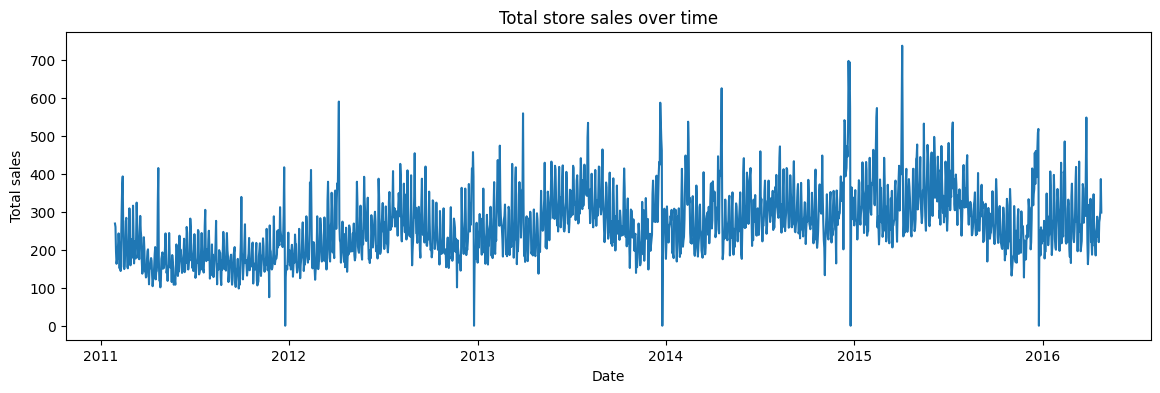

In [ ]:
# --- Total store sales over time ---
store_daily = df.groupby("date")["sales"].sum().sort_index()

plt.figure(figsize=(14, 4))
plt.plot(store_daily.index, store_daily.values)
plt.title("Total store sales over time")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.show()

In [84]:
plt.savefig(FIG_DIR / "Total store sales over time", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

## Day-of-week seasonality

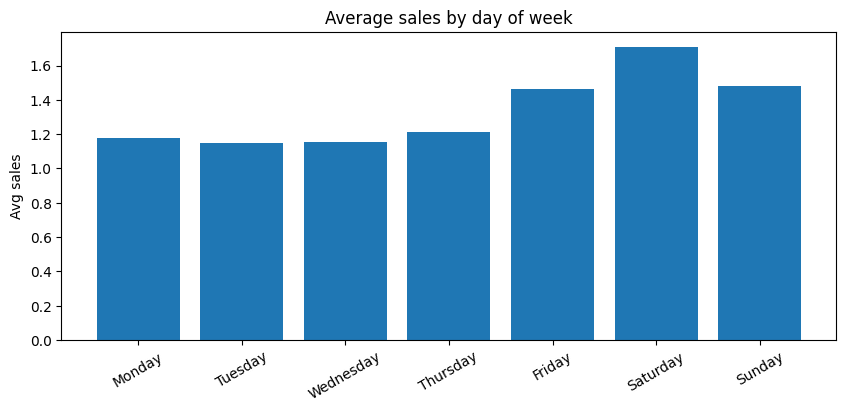

In [85]:
dow = df.assign(dow=df["date"].dt.day_name()).groupby("dow")["sales"].mean()
# order by weekday
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = dow.reindex(order)

plt.figure(figsize=(10, 4))
plt.bar(dow.index, dow.values)
plt.title("Average sales by day of week")
plt.xticks(rotation=30)
plt.ylabel("Avg sales")
plt.show()

In [86]:
plt.savefig(FIG_DIR / "Average sales by day of week", bbox_inches="tight", dpi=150)

<Figure size 640x480 with 0 Axes>

In [87]:
FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## EDA Summary & Modeling Implications

### Key findings (sample: 1 store × 200 items)
1. Demand is strongly zero-inflated (~60% zero sales), indicating intermittent rather than continuous demand.
2. Sales distributions are highly right-skewed with bursty behavior.
3. Event-related features are sparse by design and primarily represent “no event” states.
4. `sell_price` shows non-trivial missingness (~15%), which appears structural but requires validation against sales patterns.
5. Temporal structure dominates cross-sectional variation, motivating time-aware feature engineering and evaluation.

### Modeling implications
- Zero sales should be treated as valid observations.
- Evaluation should rely on time-aware splits and metrics robust to intermittency (e.g., MAE / sMAPE).
- Lagged and rolling features are likely more informative than heavy smoothing.
- Event features should be encoded explicitly as “no event” vs “event”.
- Price imputation strategies should be chosen only after validating missingness mechanisms.
